In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

## 1.导入数据与清洗

In [4]:
train = pd.read_excel('Data Dictionary.xls')
cs_test = pd.read_csv('cs-test.csv')
cs_training = pd.read_csv('cs-training.csv')
sampleEntry = pd.read_csv('sampleEntry.csv')

### 1.1 查看数据

In [5]:
df = cs_training
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


### 1.2 初步清洗

#### 总览

In [6]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [7]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


#### 清洗'RevolvingUtilizationOfUnsecuredLine'

In [8]:
df.loc[df['RevolvingUtilizationOfUnsecuredLines']>1,'RevolvingUtilizationOfUnsecuredLines']=1

#### 清洗'age'

In [9]:
df['age'] = df['age'].clip(upper=100)
df['age'] = df['age'].replace(0,float('nan'))
df['age'] = df['age'].fillna(df['age'].median())

In [10]:
df['age'].describe()

count    150000.000000
mean         52.295233
std          14.770153
min          21.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         100.000000
Name: age, dtype: float64

#### 清洗'NumberOfTime30-59DaysPastDueNotWorse'

In [11]:
df['NumberOfTime30-59DaysPastDueNotWorse'] = df['NumberOfTime30-59DaysPastDueNotWorse'].clip(upper=21)
df['NumberOfTime30-59DaysPastDueNotWorse'] = df['NumberOfTime30-59DaysPastDueNotWorse'].replace(21,float('nan'))
df['NumberOfTime30-59DaysPastDueNotWorse'] = df['NumberOfTime30-59DaysPastDueNotWorse'].fillna(df['NumberOfTime30-59DaysPastDueNotWorse'].median())

In [12]:
df['NumberOfTime30-59DaysPastDueNotWorse'].describe()

count    150000.000000
mean          0.245353
std           0.697231
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          13.000000
Name: NumberOfTime30-59DaysPastDueNotWorse, dtype: float64

#### 清洗'DebtRatio'

In [13]:
df.loc[df['DebtRatio']>10,'DebtRatio'] = float('nan')
df['DebtRatio'] = df['DebtRatio'].fillna(df['DebtRatio'].median())

In [14]:
df['DebtRatio'].describe()

count    150000.000000
mean          0.393996
std           0.664870
min           0.000000
25%           0.175074
50%           0.290065
75%           0.420116
max          10.000000
Name: DebtRatio, dtype: float64

#### 清洗'MonthlyIncome'

In [15]:
df['MonthlyIncome_missing'] = df['MonthlyIncome'].isnull().astype(int) #0/1表示
df.loc[df['MonthlyIncome']==0,'MonthlyIncome'] = float('nan')
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())

#### 清洗'NumberOfOpenCreditLinesAndLoans'

In [16]:
df['NumberOfOpenCreditLinesAndLoans'].describe()

count    150000.000000
mean          8.452760
std           5.145951
min           0.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          58.000000
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

#### 清洗'NumberOfTimes90DaysLate'

In [17]:
df['NumberOfTimes90DaysLate'].describe()

count    150000.000000
mean          0.265973
std           4.169304
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTimes90DaysLate, dtype: float64

In [18]:
df['NumberOfTimes90DaysLate'].value_counts().sort_index()

NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

In [19]:
df['NumberOfTimes90DaysLate'] = df['NumberOfTimes90DaysLate'].replace([96,98],float('nan'))
df['NumberOfTimes90DaysLate'] = df['NumberOfTimes90DaysLate'].fillna(df['NumberOfTimes90DaysLate'].median())

#### 清洗 'NumberRealEstateLoansOrLines'

In [20]:
df['NumberRealEstateLoansOrLines'].describe()

count    150000.000000
mean          1.018240
std           1.129771
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          54.000000
Name: NumberRealEstateLoansOrLines, dtype: float64

#### 清洗'NumberOfTime60-89DaysPastDueNotWorse'

In [21]:
df['NumberOfTime60-89DaysPastDueNotWorse'].describe()

count    150000.000000
mean          0.240387
std           4.155179
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          98.000000
Name: NumberOfTime60-89DaysPastDueNotWorse, dtype: float64

In [22]:
df['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index()

NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

In [23]:
df['NumberOfTime60-89DaysPastDueNotWorse'] = df['NumberOfTime60-89DaysPastDueNotWorse'].replace([96,98],float('nan'))
df['NumberOfTime60-89DaysPastDueNotWorse'] = df['NumberOfTime60-89DaysPastDueNotWorse'].fillna(df['NumberOfTime60-89DaysPastDueNotWorse'].median())

#### 清洗'NumberOfDependents'

In [24]:
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

#### 总览

In [25]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,75000.500000,0.066840,0.319196,52.295233,0.245353,0.393996,6.485016e+03,8.452760,0.090293,1.018240,0.064707,0.737413,0.198207
std,43301.414527,0.249746,0.349481,14.770153,0.697231,0.664870,1.287264e+04,5.145951,0.485107,1.129771,0.329788,1.107021,0.398650
min,1.000000,0.000000,0.000000,21.000000,0.000000,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,4.000000e+03,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.290065,5.437000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.420116,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000
max,150000.000000,1.000000,1.000000,100.000000,13.000000,10.000000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000,1.000000


In [26]:
df.isnull().sum()
df = df.drop(columns=['Unnamed: 0'])

## 2.EDA

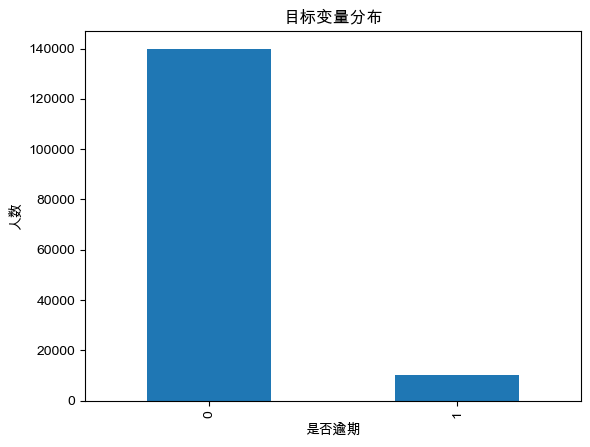

In [27]:
plt.rcParams['font.family'] = 'Arial Unicode MS'
plt.rcParams['axes.unicode_minus'] = False
df['SeriousDlqin2yrs'].value_counts().plot(kind='bar')
plt.title('目标变量分布')
plt.xlabel('是否逾期')
plt.ylabel('人数')
plt.show()

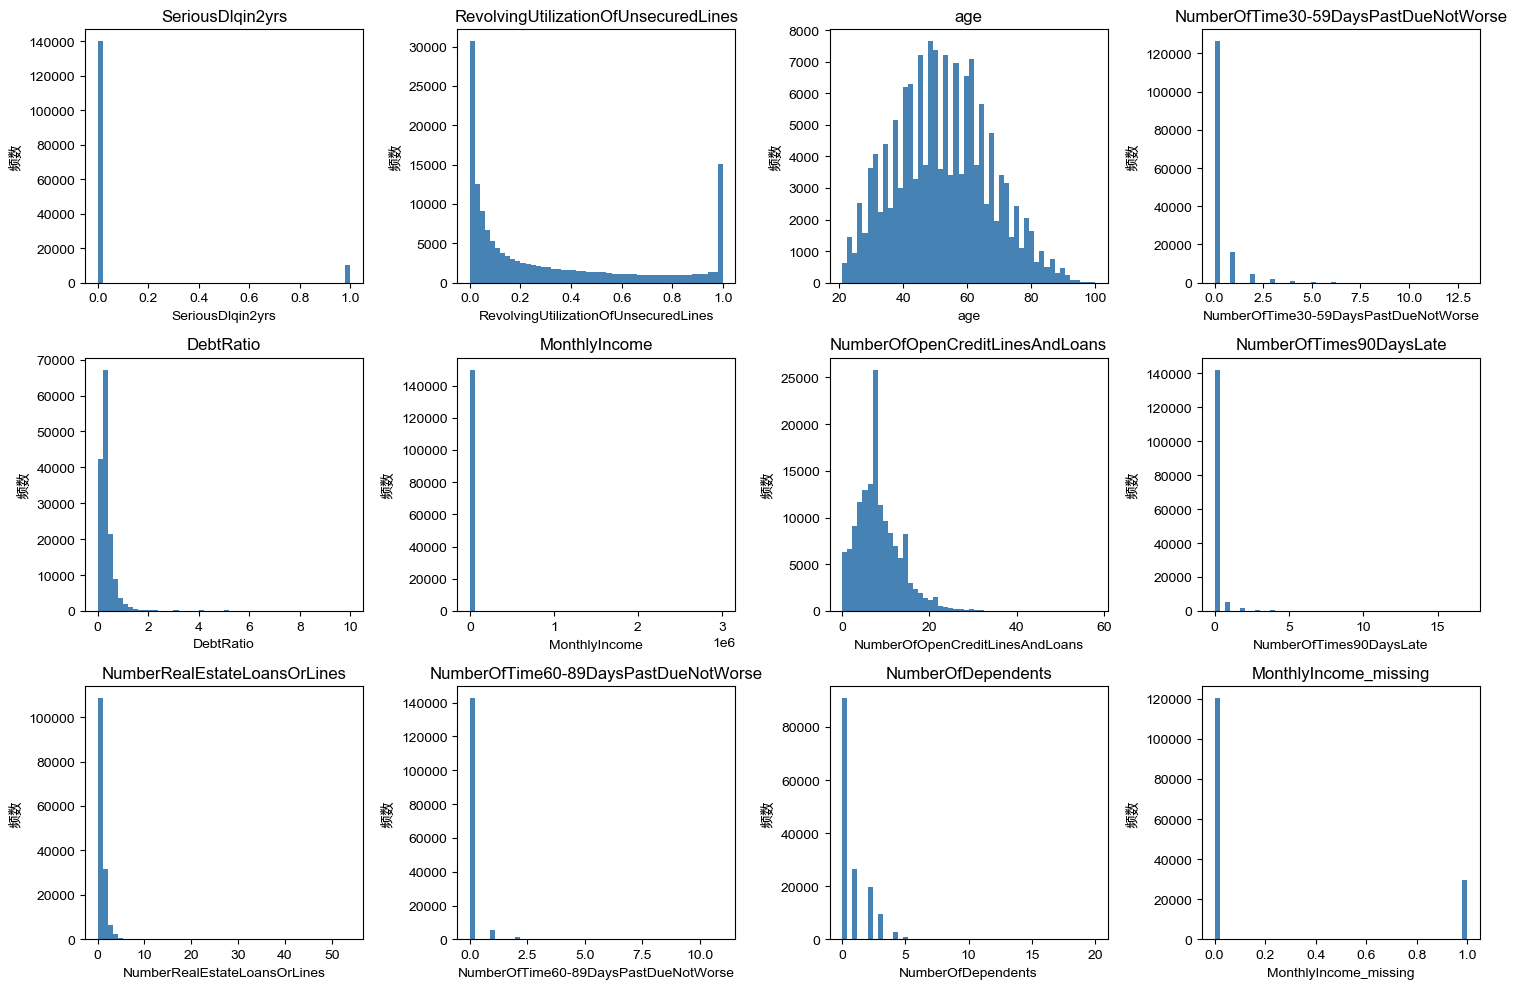

In [28]:
fig,axes = plt.subplots(3,4,figsize = (15,10))
for i,col in enumerate(df.columns):
    ax = axes.flatten()[i]
    ax.hist(df[col],bins=50,color='steelblue')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('频数')
plt.tight_layout()
plt.show()

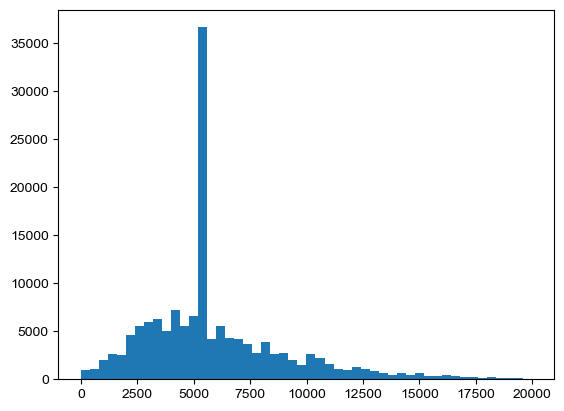

In [29]:
fig,ax = plt.subplots()
ax.hist(df[df['MonthlyIncome'] < 20000]['MonthlyIncome'], bins=50)
plt.show()

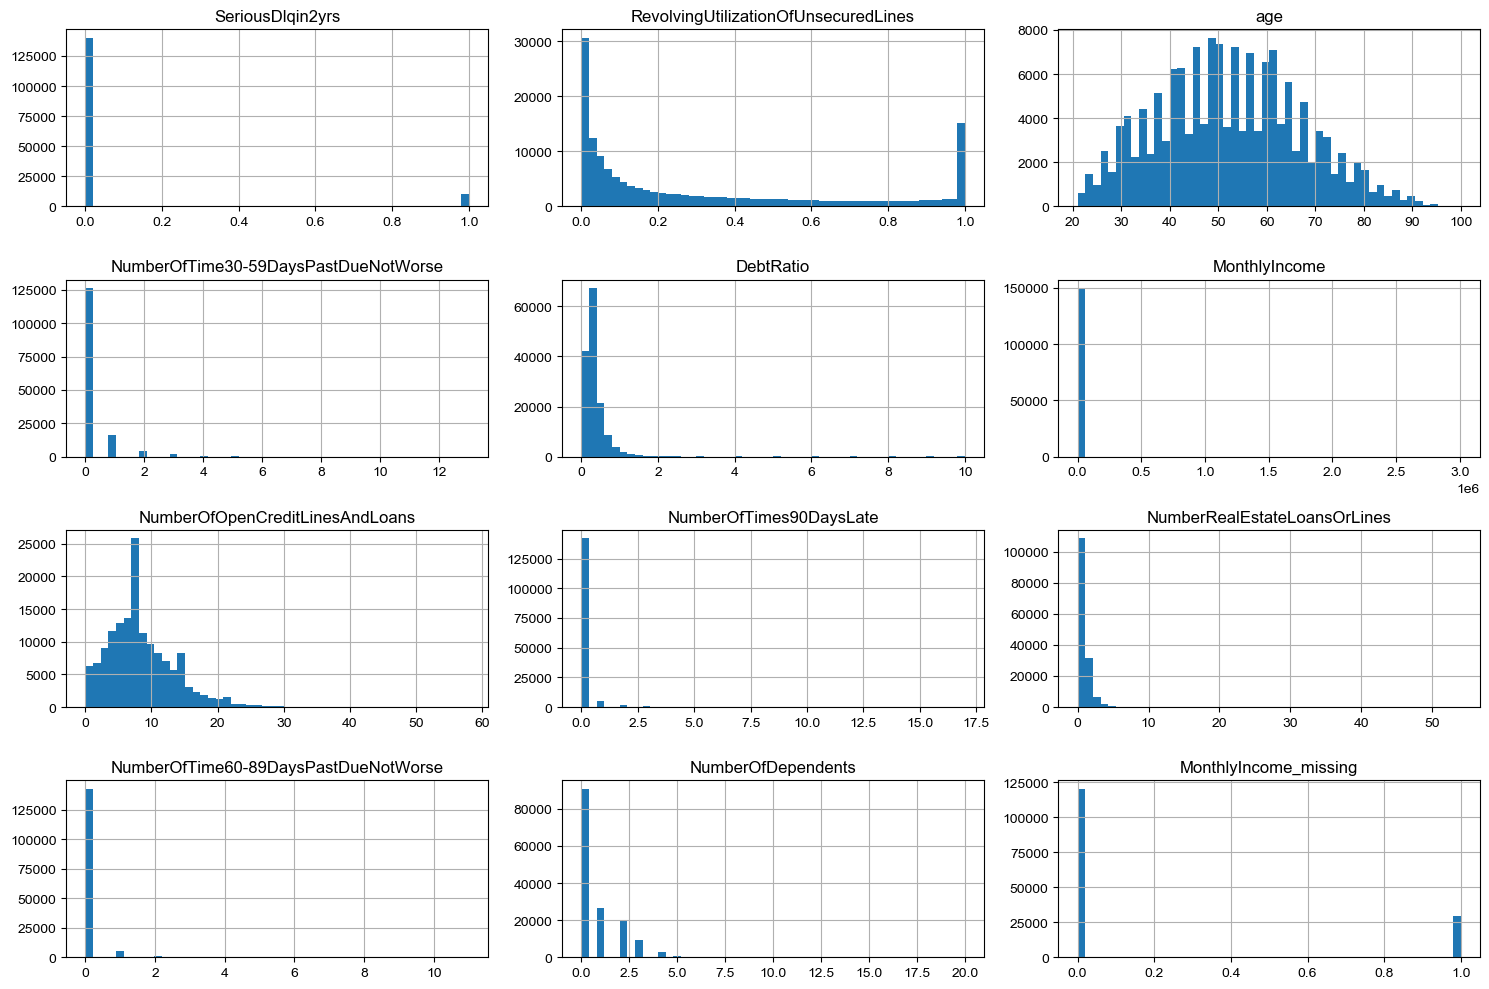

In [30]:
df.hist(bins=50,figsize=(15,10))
plt.tight_layout()
plt.show()

In [31]:
# 看逾期人群和正常人群的特征差异
df.groupby('SeriousDlqin2yrs').mean()

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_missing
SeriousDlqin2yrs,,,,,,,,,,,
0,0.293185,52.751411,0.194708,0.390343,6545.946612,8.493620,0.049824,1.020368,0.041265,0.723527,0.200480
1,0.682339,45.926491,0.952424,0.444999,5634.351885,7.882306,0.655296,0.988530,0.391981,0.931279,0.166467


## 3.WOE and IV

In [32]:
#分箱并计算WOE与IV
def calc_woe_iv(df,feature,target):
    #cut
    if feature.startswith('NumberOfTime'):
        bins = [-1,1,2,3,4,5,6,7,8,9,100]
        df['bin'] = pd.cut(df[feature],bins,right=False)
    else:
        bins=10
        df['bin'] = pd.qcut(df[feature],q=bins,duplicates='drop')
    #bad/good
    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()
    #groupby
    grouped = df.groupby('bin')[target].agg(['count','sum'])
    grouped.columns = ['total','bad']
    grouped['good'] = grouped['total'] - grouped['bad']
    #WOE/IV
    grouped['bad_rate'] = grouped['bad']/total_bad
    grouped['good_rate'] = grouped['good']/total_good
    grouped['woe'] = np.log(grouped['good_rate'] / grouped['bad_rate'])
    grouped['iv'] = (grouped['good_rate'] - grouped['bad_rate']) * grouped['woe']
    df.drop(columns=['bin'],inplace=True)
    return grouped,grouped['iv'].sum()

In [33]:
#汇总IV 选择回归特征值
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']

iv_results = {}
for feature in features:
    try:
        result, iv = calc_woe_iv(df, feature, 'SeriousDlqin2yrs')
        iv_results[feature] = iv
        print(f'{feature}: IV = {iv:.4f}')
    except Exception as e:
        print(f'{feature}: 报错 - {e}')

# 按IV从大到小排序
iv_series = pd.Series(iv_results).sort_values(ascending=False)
print('\n=== IV 汇总 ===')
print(iv_series)

RevolvingUtilizationOfUnsecuredLines: IV = 1.1134
age: IV = 0.2592
NumberOfTime30-59DaysPastDueNotWorse: IV = 0.7048
DebtRatio: IV = 0.0667
MonthlyIncome: IV = 0.0731
NumberOfOpenCreditLinesAndLoans: IV = 0.0669
NumberOfTimes90DaysLate: IV = 0.8298
NumberRealEstateLoansOrLines: IV = 0.0121
NumberOfTime60-89DaysPastDueNotWorse: IV = 0.5534
NumberOfDependents: IV = 0.0250
MonthlyIncome_missing: IV = 0.0000

=== IV 汇总 ===
RevolvingUtilizationOfUnsecuredLines    1.113378
NumberOfTimes90DaysLate                 0.829836
NumberOfTime30-59DaysPastDueNotWorse    0.704842
NumberOfTime60-89DaysPastDueNotWorse    0.553362
age                                     0.259165
MonthlyIncome                           0.073086
NumberOfOpenCreditLinesAndLoans         0.066892
DebtRatio                               0.066735
NumberOfDependents                      0.024965
NumberRealEstateLoansOrLines            0.012091
MonthlyIncome_missing                   0.000000
dtype: float64


In [34]:
#计算相关系数,决定是否要删除某特征
df[['NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse']].corr()

,NumberOfTimes90DaysLate,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse
NumberOfTimes90DaysLate,1.000000,0.218233,0.294684
NumberOfTime30-59DaysPastDueNotWorse,0.218233,1.000000,0.305956
NumberOfTime60-89DaysPastDueNotWorse,0.294684,0.305956,1.000000


In [35]:
#仅输出grouped
def calc_woe(df,feature,target):
    #cut
    if feature.startswith('NumberOfTime'):
        bins = [-1,1,2,3,4,5,6,7,8,9,100]
        df['bin'] = pd.cut(df[feature],bins,right=False)
    else:
        bins=10
        df['bin'] = pd.qcut(df[feature],q=bins,duplicates='drop')
    #bad/good
    total_good = (df[target] == 0).sum()
    total_bad = (df[target] == 1).sum()
    #groupby
    grouped = df.groupby('bin')[target].agg(['count','sum'])
    grouped.columns = ['total','bad']
    grouped['good'] = grouped['total'] - grouped['bad']
    #WOE/IV
    grouped['bad_rate'] = grouped['bad']/total_bad
    grouped['good_rate'] = grouped['good']/total_good
    grouped['woe'] = np.log(grouped['good_rate'] / grouped['bad_rate'])
    grouped['iv'] = (grouped['good_rate'] - grouped['bad_rate']) * grouped['woe']
    return grouped

In [36]:
#WOE代替原值的表
df_woe = pd.DataFrame(index=df.index)
targe_woe=['RevolvingUtilizationOfUnsecuredLines','NumberOfTimes90DaysLate','NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','age']
for i in targe_woe:
    x=calc_woe(df,i,'SeriousDlqin2yrs')
    df_woe[i] = df['bin'].map(x['woe'])
df.drop(columns=['bin'],inplace=True)
df_woe

,RevolvingUtilizationOfUnsecuredLines,NumberOfTimes90DaysLate,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,age
0,-1.021066,0.368445,-1.616726,0.269053,-0.212874
1,-1.021066,0.368445,0.513985,0.269053,-0.277843
2,-0.297972,-1.957968,-0.903654,0.269053,-0.392075
3,0.688430,0.368445,0.513985,0.269053,-0.581359
4,-1.021066,0.368445,-0.903654,0.269053,-0.152756
...,...,...,...,...,...
149995,1.618324,0.368445,0.513985,0.269053,1.176177
149996,0.257409,0.368445,0.513985,0.269053,-0.277843
149997,0.688430,0.368445,0.513985,0.269053,0.314293
149998,1.019113,0.368445,0.513985,0.269053,-0.581359


## 4.回归

In [37]:
df_woe['SeriousDlqin2yrs'] = df['SeriousDlqin2yrs']

In [38]:
X = df_woe.drop(columns=['SeriousDlqin2yrs'])
y = df_woe['SeriousDlqin2yrs']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [39]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [40]:
print(lr.coef_)
print(lr.intercept_)

[[-0.66139216 -0.53474604 -0.52621507 -0.41078905 -0.44140863]]
[-2.61144386]


In [41]:
y_pred = lr.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_pred))

0.8523374109316161


In [42]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
ks = max(tpr - fpr)
print(f'KS = {ks:.4f}')

KS = 0.5483


评分卡

In [47]:
BASE_SCORE = 600
PDO = 20
BASE_ODDS = 1/20
factor = PDO / np.log(2)
offset = BASE_SCORE - factor*np.log(BASE_ODDS)

In [53]:
coefs = lr.coef_[0]
intercept = lr.intercept_[0]
feature_names = X_train.columns.tolist()

base_score = offset - factor*intercept
print(f'基础分:{base_score:.2f}')
print()

print('各变量得分权重:')
for feat, coef in zip(feature_names, coefs):
    weight = -coef * factor
    print(f'{feat}: {weight:.4f}')

基础分:761.79

各变量得分权重:
RevolvingUtilizationOfUnsecuredLines: 19.0837
NumberOfTimes90DaysLate: 15.4295
NumberOfTime30-59DaysPastDueNotWorse: 15.1834
NumberOfTime60-89DaysPastDueNotWorse: 11.8529
age: 12.7364


In [54]:
woe_tables = {}
for feat in feature_names:
    grouped,iv = calc_woe_iv(df, feat, 'SeriousDlqin2yrs')
    woe_tables[feat] = grouped
    print(f'{feat} IV={iv:.4f}')

RevolvingUtilizationOfUnsecuredLines IV=1.1134
NumberOfTimes90DaysLate IV=0.8298
NumberOfTime30-59DaysPastDueNotWorse IV=0.7048
NumberOfTime60-89DaysPastDueNotWorse IV=0.5534
age IV=0.2592


,total,bad,good,bad_rate,good_rate,woe,iv
bin,,,,,,,
"(20.999, 33.0]",17084,1940,15144,0.193497,0.108192,-0.581359,0.049593
"(33.0, 39.0]",14919,1430,13489,0.142629,0.096368,-0.392075,0.018138
"(39.0, 44.0]",15799,1365,14434,0.136146,0.103119,-0.277843,0.009176
"(44.0, 48.0]",14741,1200,13541,0.119689,0.096739,-0.212874,0.004885
"(48.0, 52.0]",14827,1142,13685,0.113904,0.097768,-0.152756,0.002465
"(52.0, 56.0]",14214,935,13279,0.093258,0.094868,0.017118,0.000028
"(56.0, 61.0]",16878,839,16039,0.083682,0.114586,0.314293,0.009713
"(61.0, 65.0]",12939,485,12454,0.048374,0.088974,0.609373,0.024740
"(65.0, 72.0]",14258,380,13878,0.037901,0.099147,0.961614,0.058895


In [109]:
scorecard = []
for feat,coef in zip(feature_names,coefs):
    grouped = woe_tables[feat]
    for bin_label,row in grouped.iterrows():
        woe_val = row['woe']
        score = round(-coef*woe_val*factor)
        scorecard.append({
            '变量':feat,
            '分箱':str(bin_label),
            'WOE':round(woe_val,4),
            '分值':score
        })
scorecard_df = pd.DataFrame(scorecard)

In [60]:
scorecard

[{'变量': 'RevolvingUtilizationOfUnsecuredLines',
  '分箱': '(-0.001, 0.00297]',
  'WOE': np.float64(1.0191),
  '分值': 19},
 {'变量': 'RevolvingUtilizationOfUnsecuredLines',
  '分箱': '(0.00297, 0.0192]',
  'WOE': np.float64(1.6477),
  '分值': 31},
 {'变量': 'RevolvingUtilizationOfUnsecuredLines',
  '分箱': '(0.0192, 0.0435]',
  'WOE': np.float64(1.6183),
  '分值': 31},
 {'变量': 'RevolvingUtilizationOfUnsecuredLines',
  '分箱': '(0.0435, 0.0832]',
  'WOE': np.float64(1.3007),
  '分值': 25},
 {'变量': 'RevolvingUtilizationOfUnsecuredLines',
  '分箱': '(0.0832, 0.154]',
  'WOE': np.float64(1.0806),
  '分值': 21},
 {'变量': 'RevolvingUtilizationOfUnsecuredLines',
  '分箱': '(0.154, 0.271]',
  'WOE': np.float64(0.6884),
  '分值': 13},
 {'变量': 'RevolvingUtilizationOfUnsecuredLines',
  '分箱': '(0.271, 0.445]',
  'WOE': np.float64(0.2574),
  '分值': 5},
 {'变量': 'RevolvingUtilizationOfUnsecuredLines',
  '分箱': '(0.445, 0.699]',
  'WOE': np.float64(-0.298),
  '分值': -6},
 {'变量': 'RevolvingUtilizationOfUnsecuredLines',
  '分箱': '(0.69

In [61]:
def calc_score(row):
    total = base_score
    for feat,conef in zip(feature_names,coefs):
        woe_val = row[feat]
        total += float(-coef*woe_val*factor)
    return round(total)

In [72]:
X_test_copy = X_test.copy()
X_test_copy['score'] = X_test_copy.apply(calc_score,axis=1)
X_test_copy['label'] = y_test.values

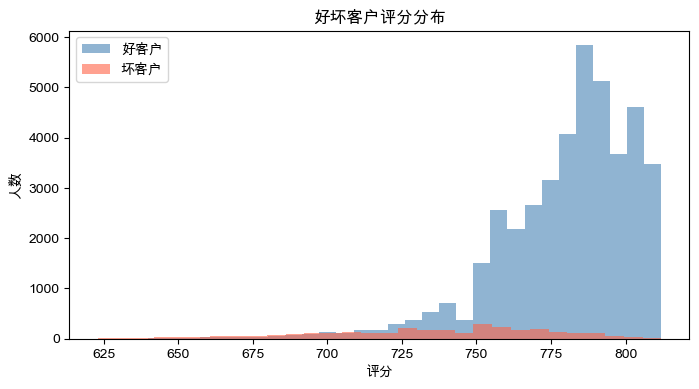

In [73]:
good = X_test_copy[X_test_copy['label'] == 0]['score']
bad  = X_test_copy[X_test_copy['label'] == 1]['score']
plt.figure(figsize=(8, 4))
plt.hist(good, bins=30, alpha=0.6, label='好客户', color='steelblue')
plt.hist(bad,  bins=30, alpha=0.6, label='坏客户', color='tomato')
plt.xlabel('评分')
plt.ylabel('人数')
plt.title('好坏客户评分分布')
plt.legend()
plt.show()

In [100]:
scores_sorted = np.sort(X_test_copy['score'].unique())
ks_list = {}
for threshold in scores_sorted:
    pred = (X_test_copy['score']<threshold).astype(int)
    tp = ((pred == 1) & (X_test_copy['label'] == 1)).sum()
    fp = ((pred == 1) & (X_test_copy['label'] == 0)).sum()
    fn = ((pred == 0) & (X_test_copy['label'] == 1)).sum()
    tn = ((pred == 0) & (X_test_copy['label'] == 0)).sum()
    
    tpr = tp/(tp+fn) if (tp+fn) >0 else 0
    fpr = fp/(fp+tn) if (fp+tn) >0 else 0

    ks_list[threshold] = tpr-fpr

In [105]:
best_threshold = max(ks_list,key=ks_list.get)

In [106]:
print(best_threshold, ks_list[best_threshold])

768 0.5519815957852153


In [115]:
from IPython.display import display
print('='*60)
print('信用评分卡报告')
print('='*60)
print(f'基础分: {base_score:.0f}')
print(f'AUC:    {roc_auc_score(y_test, y_pred):.4f}')
print(f'KS:     {ks:.4f}')
print(f'最优拒贷阈值: {best_threshold}分')
print()
print('评分卡分箱得分表:')
display(scorecard_df)

信用评分卡报告
基础分: 762
AUC:    0.8523
KS:     0.5483
最优拒贷阈值: 768分

评分卡分箱得分表:


,变量,分箱,WOE,分值
0,RevolvingUtilizationOfUnsecuredLines,"(-0.001, 0.00297]",1.0191,19
1,RevolvingUtilizationOfUnsecuredLines,"(0.00297, 0.0192]",1.6477,31
2,RevolvingUtilizationOfUnsecuredLines,"(0.0192, 0.0435]",1.6183,31
3,RevolvingUtilizationOfUnsecuredLines,"(0.0435, 0.0832]",1.3007,25
4,RevolvingUtilizationOfUnsecuredLines,"(0.0832, 0.154]",1.0806,21
5,RevolvingUtilizationOfUnsecuredLines,"(0.154, 0.271]",0.6884,13
6,RevolvingUtilizationOfUnsecuredLines,"(0.271, 0.445]",0.2574,5
7,RevolvingUtilizationOfUnsecuredLines,"(0.445, 0.699]",-0.2980,-6
8,RevolvingUtilizationOfUnsecuredLines,"(0.699, 0.981]",-1.0211,-19
9,RevolvingUtilizationOfUnsecuredLines,"(0.981, 1.0]",-1.4374,-27
